## Loading / Preprocessing of Data

#### training_set 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


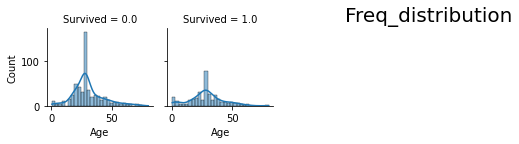

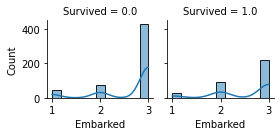

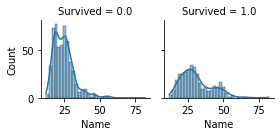

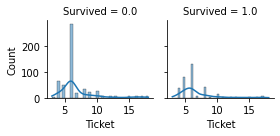

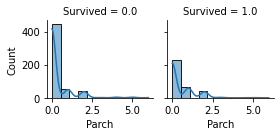

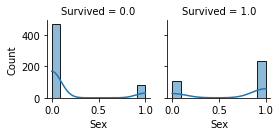

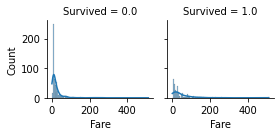

In [24]:
import pandas as pd
import seaborn as sns
import numpy as np
import pylab as py

pd.options.mode.chained_assignment = None 
df = pd.read_csv('../input/titanic/train.csv' )
df_test = pd.read_csv('../input/titanic/test.csv' )

print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())## setting_null_vals to -100
df = df.drop(['Cabin'], axis=1)
df = df.dropna(axis=0, subset=['Embarked'])

for step,i in enumerate(df['Name']):
    df['Name'].iloc[step] = str(len(i))

for step,i in enumerate(df['Ticket']):
    df['Ticket'].iloc[step] = str(len(i))

'''df['Cabin'] = df['Cabin'].astype('string')
for step,i in enumerate(df['Cabin']):
    if type(df['Cabin'].iloc[step]) == str:
        df['Cabin'].iloc[step] = str(len(i))
    else:
        df['Cabin'].iloc[step] = '0' '''
dic = {
    'Q':'1',
    'C':'2',
    'S':'3'
}

df['Embarked']=(df['Embarked']).astype('string')
for step,i in enumerate(df['Embarked']):
    if type(df['Embarked'].iloc[step]) == str and df['Embarked'].iloc[step] != '-100':
        df['Embarked'].iloc[step] = dic.get(i)
dic = {
    'male':'0',
    'female':'1'
}


df['Sex']=(df['Sex']).astype('string')
for step,i in enumerate(df['Sex']):
    if type(df['Sex'].iloc[step]) == str:
        df['Sex'].iloc[step] = dic.get(i)

       
df = df.astype('float64')
train = df

## Frequency Distrib. w.r.t all features -->>

plot = sns.displot(data=df, x="Age", col="Survived", kde=True, height = 2 )
plot.fig.suptitle("Freq_distribution",
                  fontsize=20, fontdict={"weight": "bold"}, x = 1.5)
sns.displot(data=df, x='Embarked', col='Survived', kde=True, height=2)
sns.displot(data=df, x="Name", col="Survived", kde=True, height = 2) 
sns.displot(data=df, x="Ticket", col="Survived", kde=True, height = 2) 
sns.displot(data=df, x="Parch", col="Survived", kde=True, height = 2) 
sns.displot(data=df, x="Sex", col="Survived", kde=True, height = 2)
sns.displot(data=df, x="Fare", col="Survived", kde=True, height = 2)

py.show()


## Feature Selection 

(889, 11)


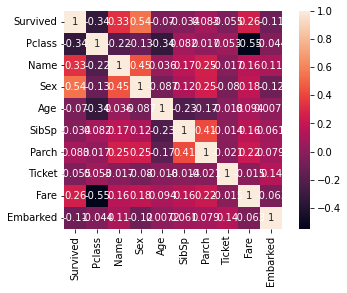

Pclass     -0.335549
Embarked   -0.108669
Age        -0.069822
Ticket     -0.054654
SibSp      -0.034040
Parch       0.083151
Fare        0.255290
Name        0.332582
Sex         0.541585
Survived    1.000000
Name: Survived, dtype: float64
(889, 9)
x_train_shape:  (889, 8)
Selected_Columns:  ['Pclass' 'Name' 'Sex' 'Age' 'Parch' 'Ticket' 'Fare' 'Embarked']


<Figure size 720x576 with 0 Axes>

In [75]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler, Normalizer


df_new = train

print(df_new.shape)
df_new = df_new.dropna()


df_label = df_new['Survived']
df_train = df_new.drop(['PassengerId'], axis=1)
df_corr = df_train.corr() 
sns.heatmap(data = df_corr, square=True, annot=True)
py.show()

print(df_train.corr()['Survived'].sort_values())

df_train = df_train.drop(['Survived'], axis=1)
print(df_train.shape)

py.figure(figsize = (10,8))

x_train = df_train.to_numpy()
y_train = df_label.to_numpy()

fs = SelectKBest(score_func=f_classif, k=8)
x_selected = fs.fit_transform(x_train,y_train)

## Scale the Data to compare on equal gounds
x_train = x_selected
x_train = StandardScaler().fit_transform(x_train)
print('x_train_shape: ',x_train.shape)

cols = df_train.columns
cols = (cols).to_numpy()
sel_cols = cols[fs.get_support()]
print('Selected_Columns: ', sel_cols)

In [76]:
df_train = pd.DataFrame(x_train, columns=sel_cols)
df_train.info()
df_e = pd.get_dummies(df_train['Embarked'], drop_first=True)
df_p = pd.get_dummies(df_train['Pclass'], drop_first=True)

df_train_final = pd.concat([df_train.drop(['Embarked', 'Pclass'], axis=1), df_e, df_p], axis=1)

x_train = df_train_final.to_numpy()
print('x_train: ', x_train.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    889 non-null    float64
 1   Name      889 non-null    float64
 2   Sex       889 non-null    float64
 3   Age       889 non-null    float64
 4   Parch     889 non-null    float64
 5   Ticket    889 non-null    float64
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    float64
dtypes: float64(8)
memory usage: 55.7 KB
x_train:  (889, 10)


#### Test_set

In [77]:
df = df_test #----For test_set_creation----- 

print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(['Cabin'], axis=1)
df = df.dropna(axis=0, subset=['Embarked'])
df = df.dropna(axis=0, subset=['Fare'])


for step,i in enumerate(df['Name']):
    df['Name'].iloc[step] = str(len(i))

for step,i in enumerate(df['Ticket']):
    df['Ticket'].iloc[step] = str(len(i))

'''df['Cabin'] = df['Cabin'].astype('string')
for step,i in enumerate(df['Cabin']):
    if type(df['Cabin'].iloc[step]) == str:
        df['Cabin'].iloc[step] = str(len(i))
    else:
        df['Cabin'].iloc[step] = '0' '''
dic = {
    'Q':'1',
    'C':'2',
    'S':'3'
}

df['Embarked']=(df['Embarked']).astype('string')
for step,i in enumerate(df['Embarked']):
    if type(df['Embarked'].iloc[step]) == str and df['Embarked'].iloc[step] != '-100':
        df['Embarked'].iloc[step] = dic.get(i)
dic = {
    'male':'0',
    'female':'1'
}


df['Sex']=(df['Sex']).astype('string')
for step,i in enumerate(df['Sex']):
    if type(df['Sex'].iloc[step]) == str:
        df['Sex'].iloc[step] = dic.get(i)
test = df.astype('float64')

##-----------For Test_set_creation------------------
test = df[sel_cols]
sub_test = test.to_numpy()
print('Test_set_shape: ', sub_test.shape)
##--------------------------------------------------

df = pd.DataFrame(sub_test, columns=sel_cols)
df.info()
df_e = pd.get_dummies(df['Embarked'], drop_first=True)
df_p = pd.get_dummies(df['Pclass'], drop_first=True)

df_final = pd.concat([df.drop(['Embarked', 'Pclass'], axis=1), df_e, df_p], axis=1)

sub_test = df_final.to_numpy()
print('sub_test: ', sub_test.shape)

sub_test = StandardScaler().fit_transform(sub_test)

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
Test_set_shape:  (417, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Pclass    417 non-null    object
 1   Name      417 non-null    object
 2   Sex       417 non-null    object
 3   Age       417 non-null    object
 4   Parch     417 non-null    object
 5   Ticket    417 non-null    object
 6   Fare      417 non-null    object
 7   Embarked  417 non-null    object
dtypes: object(8)
memory usage: 26.2+ KB
sub_test:  (417, 10)


## Training Mode

(889, 10) (889,)
--
(666, 10) (666,)
(167, 10) (167,)
(56, 10) (56,)
--
-
0.8168168168168167
{'colsample_bytree': 0.8116263038237741, 'gamma': 0.041427728613587955, 'learning_rate': 0.154717866064024, 'max_depth': 3, 'n_estimators': 193, 'subsample': 0.7827911628145541}
-
[0]	validation_0-auc:0.83706	validation_0-error:0.15569
[1]	validation_0-auc:0.88886	validation_0-error:0.16767
[2]	validation_0-auc:0.89441	validation_0-error:0.16767
[3]	validation_0-auc:0.89250	validation_0-error:0.16767
[4]	validation_0-auc:0.88861	validation_0-error:0.16767
[5]	validation_0-auc:0.89077	validation_0-error:0.16168
[6]	validation_0-auc:0.89449	validation_0-error:0.16767
[7]	validation_0-auc:0.89068	validation_0-error:0.14371
[8]	validation_0-auc:0.89465	validation_0-error:0.16767
[9]	validation_0-auc:0.89747	validation_0-error:0.16767
[10]	validation_0-auc:0.90028	validation_0-error:0.16767
[11]	validation_0-auc:0.89846	validation_0-error:0.15569
[12]	validation_0-auc:0.89805	validation_0-error:0.14

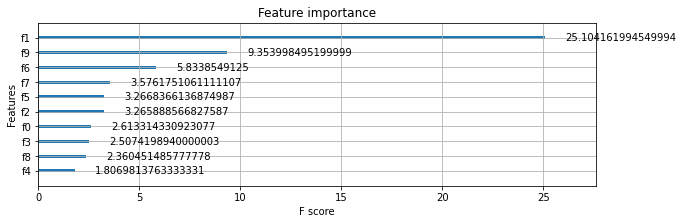

In [78]:
from scipy.stats import uniform, randint
import xgboost as xgb
from sklearn.metrics import auc, accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.decomposition import PCA

print(x_train.shape, y_train.shape)

x_t, x_val, y_t, y_val = train_test_split(x_train,y_train)
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val)
print('--')
print(x_t.shape, y_t.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)
print('--')


params = {
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 0.5),
    "learning_rate": uniform(0.003, 0.3), # default 0.1 
    "max_depth": randint(2, 6), # default 3
    "n_estimators": randint(100, 500), # default 100
    "subsample": uniform(0.6, 0.4)
}

xgb_model = xgb.XGBClassifier(eval_metric=['auc', 'error'], random_state = 1, use_label_encoder=False)

search = RandomizedSearchCV(xgb_model, param_distributions=params, random_state =1, n_iter=200, cv=3,
                            verbose=0, n_jobs=1, return_train_score=True) #cv : cross_val Split strat.
search.fit(x_t, y_t)
best_param = search.best_params_
print('-')
print(search.best_score_)
print(best_param)
print('-')

xgb_model = xgb.XGBClassifier(eval_metric=['auc', 'error'], random_state = 1, use_label_encoder=False, **best_param)

xgb_model.fit(x_t, y_t, eval_set = [(x_val, y_val)],early_stopping_rounds = 20, verbose = 1)
print('Best_iteration: {}, Best_score: {}, Best_ntree_limit: {}'.format(xgb_model.best_iteration, xgb_model.best_score, 
                                                                         xgb_model.best_ntree_limit))

yhat = xgb_model.predict(x_test)
print('Test_acc: ', accuracy_score(y_test, yhat))
print(yhat, y_test)

ax = xgb.plot_importance(xgb_model, max_num_features= x_train.shape[1], importance_type='gain', show_values=True) 

fig = ax.figure
fig.set_size_inches(10, 3)

### More Intuition

--- Axis1 = ref_val, Axis0 = pred_val ---
Confusion_Matrix: 
[[ 41   7]
 [ 12 107]]
Precsion_Score:  0.8541666666666666
Recall_Score:  0.7735849056603774
y_hat_shape:  (167, 2)

random_classifier: ROC AUC=0.500
XGBclassifier: ROC AUC=0.910


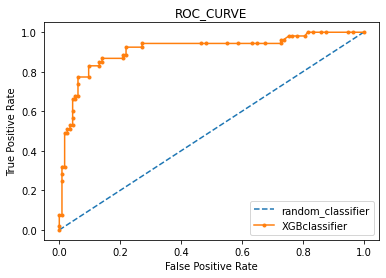

auc-score:  0.8379633417680535
f1-score:  0.811881188118812


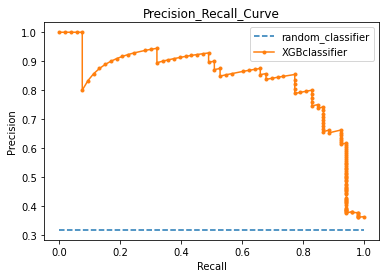

In [79]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve
print('--- Axis1 = ref_val, Axis0 = pred_val ---')

yhat = xgb_model.predict_proba(x_val)
ypred = xgb_model.predict(x_val)
print('Confusion_Matrix: ')
print(confusion_matrix(y_val, ypred, labels = [1,0]).T)
print('Precsion_Score: ', precision_score(y_val, ypred, labels = [1,0]))
print('Recall_Score: ', recall_score(y_val, ypred, labels = [1,0]))

print('y_hat_shape: ',yhat.shape)
yhat = yhat[:,1]

ns_probs = [0 for _ in range(len(y_val))]
ns_auc = roc_auc_score(y_val, ns_probs, labels = [1,0])
lr_auc = roc_auc_score(y_val, yhat, labels = [1,0])
print()
print('random_classifier: ROC AUC=%.3f' % (ns_auc))
print('XGBclassifier: ROC AUC=%.3f' % (lr_auc))

ns_fpr, ns_tpr, _ = roc_curve(y_val, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_val, yhat)

py.plot(ns_fpr, ns_tpr, linestyle='--', label='random_classifier')
py.plot(lr_fpr, lr_tpr, marker='.', label='XGBclassifier')
py.xlabel('False Positive Rate')
py.ylabel('True Positive Rate')
py.legend()
py.title('ROC_CURVE')
py.show()

lr_precision, lr_recall, _ = precision_recall_curve(y_val, yhat)
print('auc-score: ',auc(lr_recall, lr_precision))
print('f1-score: ', f1_score(y_val, ypred, labels = [1,0]))
no_skill = len(y_val[y_val==1]) / len(y_val)
py.plot([0, 1], [no_skill, no_skill], linestyle='--', label='random_classifier')
py.plot(lr_recall, lr_precision, marker='.', label='XGBclassifier')
py.xlabel('Recall')
py.ylabel('Precision')
py.legend()
py.title('Precision_Recall_Curve')
py.show()


(889, 10) (889,)


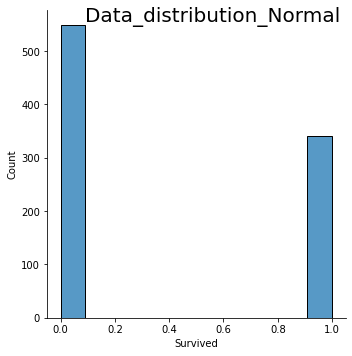

Dead:  549  ,Survived:  340
Distrib_Ratio:  1.6147058823529412
----------------------------------------------------------------------------------------------------
f1_score:  0.8326608784473951
----------------------------------------------------------------------------------------------------


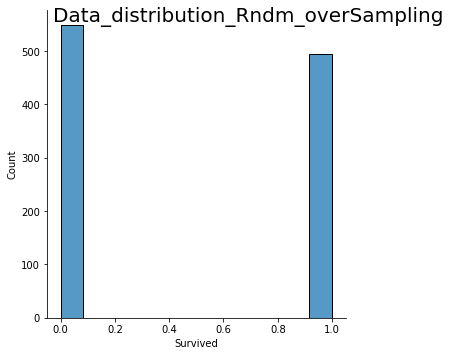

y_sur:  (494,) y_dead:  (549,)
----------------------------------------------------------------------------------------------------
Random_over_f1_score:  0.8263610827374873
----------------------------------------------------------------------------------------------------


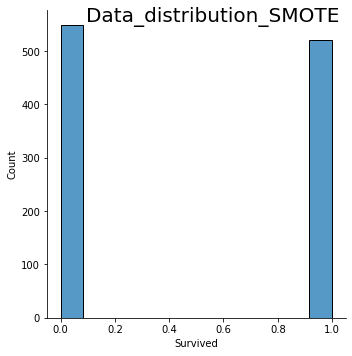

y_sur:  (521,) y_dead:  (549,)
----------------------------------------------------------------------------------------------------
Smote_f1_score:  0.8270429009193053
----------------------------------------------------------------------------------------------------


In [80]:
import pylab as py
from sklearn.model_selection import KFold, RepeatedStratifiedKFold
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn import tree

df_train = train
label = df_train['Survived']

print(x_train.shape, y_train.shape)

t_model = xgb_model

plot = sns.displot(data=label, kde=False, height=5)
plot.fig.suptitle("Data_distribution_Normal",fontsize=20, fontdict={"weight": "bold"}, x = 0.6)
py.show()

label = label.to_numpy()
label_0 = label[label==0]
label_1 = label[label==1]
print('Dead: ',label_0.shape[0], ' ,Survived: ',label_1.shape[0])
print('Distrib_Ratio: ',label_0.shape[0]/label_1.shape[0]) 

over = RandomOverSampler(sampling_strategy = 0.9)
s_over = SMOTE(sampling_strategy = 0.95, k_neighbors = 5)
s_under = RandomUnderSampler(sampling_strategy = 0.96)

steps2 = [('o', over), ('model', t_model)]
pipln2 = Pipeline(steps = steps2)

steps1 = [('model', t_model)]
pipln1 = Pipeline(steps = steps1)

pipln3 = Pipeline(steps = [('o', s_over),('u', s_under), ('model',t_model)])

cv = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 5, random_state =1)

score2 = cross_val_score(pipln2, x_train, y_train, cv=cv, scoring='f1_micro', n_jobs=1)
score2 = np.mean(score2)
score1 = cross_val_score(pipln1, x_train, y_train, cv=cv, scoring='f1_micro', n_jobs=1)
score1 = np.mean(score1)
print('--'*50)
print('f1_score: ', score1)
print('--'*50)

x_over, y_over = over.fit_resample(x_train, y_train)
df_over = pd.DataFrame(y_over, columns = {'Survived'} )
df_over = df_over['Survived']
plot1 = sns.displot(df_over, kde=False, height=5)
plot1.fig.suptitle("Data_distribution_Rndm_overSampling",fontsize=20, fontdict={"weight": "bold"}, x = 0.7)
py.show()

print('y_sur: ', y_over[y_over==1].shape,'y_dead: ', y_over[y_over==0].shape)
print('--'*50)
print('Random_over_f1_score: ', score2)
print('--'*50)

score3 = cross_val_score(pipln3, x_train, y_train, cv=cv, scoring='f1_micro', n_jobs=1)
score3 = np.mean(score3)

x_over, y_over = s_over.fit_resample(x_train, y_train)
df_over = pd.DataFrame(y_over, columns = {'Survived'} )
df_over = df_over['Survived']
plot1 = sns.displot(df_over, kde=False, height=5)
plot1.fig.suptitle("Data_distribution_SMOTE",fontsize=20, fontdict={"weight": "bold"}, x = 0.6)
py.show()

print('y_sur: ', y_over[y_over==1].shape,'y_dead: ', y_over[y_over==0].shape)
print('--'*50)
print('Smote_f1_score: ', score3)
print('--'*50)


### Some_Visualizations

x_pca_shape:  (889, 2)  ,y_train_shape:  (889,)


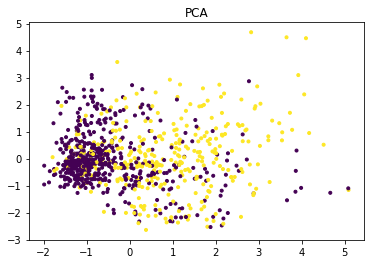

x_lle_shape:  (889, 3)


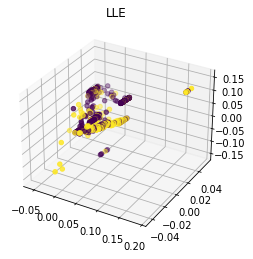

x_iso_shape:  (889, 2)


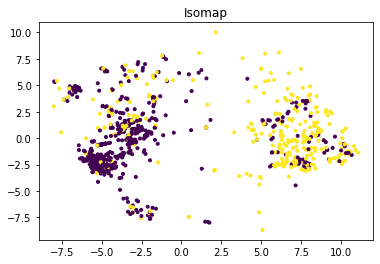

x_tsne1_shape:  (889, 2)
x_tsne2_shape:  (889, 3)


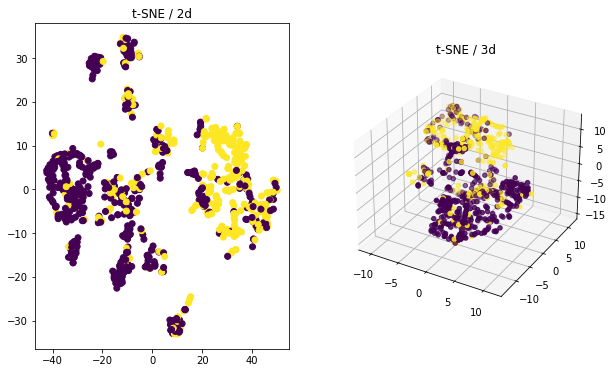

In [81]:
import pylab as py
from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding, Isomap, TSNE
import matplotlib.pyplot as plt

pca = PCA(n_components = 0.3)
x_pca = pca.fit_transform(x_train)
print('x_pca_shape: ', x_pca.shape, ' ,y_train_shape: ',y_train.shape)

py.title('PCA')
py.scatter(x_pca[:,0],x_pca[:,1], c = y_train, marker = '.')
py.show()

embedding = LocallyLinearEmbedding(n_components=3)
x_lle= embedding.fit_transform(x_train)
print('x_lle_shape: ',x_lle.shape)

fig = plt.figure()
axs1 = fig.add_subplot(1,1,1, projection='3d')
axs1.set(title='LLE')
axs1.scatter(x_lle[:, 0], x_lle[:, 1], x_lle[:,2], c=y_train)
py.show()

embedding = Isomap(n_components=2)
x_iso= embedding.fit_transform(x_train)
print('x_iso_shape: ',x_iso.shape)
py.title('Isomap')
py.scatter(x_iso[:,0],x_iso[:,1], c = y_train, marker = '.')
py.show()

embedding1 = TSNE(n_components=2)
embedding2 = TSNE(n_components=3)
x_tsne1= embedding1.fit_transform(x_train)
x_tsne2= embedding2.fit_transform(x_train)
print('x_tsne1_shape: ',x_tsne1.shape)
print('x_tsne2_shape: ',x_tsne2.shape)

fig = plt.figure(figsize=(10,6))
axs1 = fig.add_subplot(1,2,1)
axs1.set(title='t-SNE / 2d')
axs1.scatter(x_tsne1[:, 0], x_tsne1[:, 1], c=y_train)
axs2 = fig.add_subplot(1,2,2, projection='3d')
axs2.set(title='t-SNE / 3d')
axs2.scatter(x_tsne2[:, 0], x_tsne2[:, 1],x_tsne2[:, 2], c=y_train)
py.show()

## Inference Mode

In [82]:
print(sub_test.shape)
xgb_pred = xgb_model.predict(s_test)
print(test)
submission = pd.concat([df_test.PassengerId, pd.DataFrame(xgb_pred)], axis = 'columns')
submission.columns = ["PassengerId", "Survived"]
submission.to_csv('submission.csv', header = True, index = False) #--- for saving
(submission)

(417, 10)
     Pclass Name Sex   Age  Parch Ticket      Fare Embarked
0         3   16   0  34.5      0      6    7.8292        1
1         3   32   1  47.0      0      6    7.0000        3
2         2   25   0  62.0      0      6    9.6875        1
3         3   16   0  27.0      0      6    8.6625        3
4         3   44   1  22.0      1      7   12.2875        3
..      ...  ...  ..   ...    ...    ...       ...      ...
413       3   18   0  27.0      0      9    8.0500        3
414       1   28   1  39.0      0      8  108.9000        2
415       3   28   0  38.5      0     18    7.2500        3
416       3   19   0  27.0      0      6    8.0500        3
417       3   24   0  27.0      1      4   22.3583        2

[417 rows x 8 columns]


,PassengerId,Survived
0,892,0.0
1,893,0.0
2,894,0.0
3,895,0.0
4,896,0.0
...,...,...
413,1305,1.0
414,1306,0.0
415,1307,0.0
416,1308,0.0
